In [7]:
# ================================================================
# NOTEBOOK: Disparity + Modularity — Unthresholded connectomes
# Datasets 1 and 2 excluded (high-strength scanner artefact)
# ================================================================

# ── Cell 1: Imports ───────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymatreader import read_mat
import networkx as nx
from joblib import Parallel, delayed
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from scipy.ndimage import uniform_filter1d
os.makedirs('results/disparity', exist_ok=True)
os.makedirs('results/communities', exist_ok=True)
os.makedirs('results/thresholding', exist_ok=True)


In [12]:

# ── Cell 2: Load raw connectomes and demographics ─────────────────
conn_all= read_mat('preprocdata/all_data.mat')['all_data']['connectomes'] #variable density for our analysis.

demo_all   = pd.read_csv('preprocdata/demographics.csv')  # (N_all, 10)

print(f"Raw: {conn_all.shape} | Demo: {demo_all.shape}")
print(demo_all.columns.tolist())

# ── Cell 3: Filter — neurotypical, no outliers, excl. ds 1 & 2 ───
mask = (
    (demo_all['group']         == 1) &
    (demo_all['outlier_index'] == 0) #&
    #(~demo_all['dataset'].isin([1, 2,3,4,5]))
)
demo   = demo_all[mask].reset_index(drop=True)
conn   = conn_all[mask.values]   # keep same row order

print(f"After filter: N={len(demo)} | Datasets: {sorted(demo['dataset'].unique())}")
print(f"Age: {demo['age'].min():.1f} – {demo['age'].max():.1f}")
print(demo[['age','sex','dataset']].describe())

c:\Users\Ale\miniconda3\envs\snakes\Lib\site-packages\pymatreader\utils.py:304: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


Raw: (4216, 90, 90) | Demo: (4216, 6)
['age', 'sex', 'dataset', 'atlas', 'group', 'outlier_index']
After filter: N=3889 | Datasets: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Age: 0.0 – 90.0
               age          sex      dataset
count  3889.000000  3889.000000  3889.000000
mean     30.667267     0.523528     6.263821
std      23.889823     0.499510     2.522498
min       0.000000     0.000000     1.000000
25%      11.000000     0.000000     6.000000
50%      27.000000     1.000000     7.000000
75%      45.000000     1.000000     8.000000
max      90.000000     1.000000     9.000000


In [3]:
# ── Cell: Extract nodal long-format data ─────────────────────────
# Each row = one node from one subject
# Columns: age, sex, dataset, subject_id, node_idx, Y_obs_node,
#          Y_null_node, Ratio_node, strength_node, degree_node
# NOTE: nodes within a subject are NOT independent — the R GAM
#       below uses s(subject_id, bs="re") as a random effect to
#       account for within-subject correlation.

import numpy as np
import pandas as pd

N_subj, N_roi, _ = conn.shape
rows = []

for i in range(N_subj):
    adj = conn[i].copy()
    np.fill_diagonal(adj, 0)

    k = (adj > 0).sum(axis=1).astype(float)      # per-node degree
    s = adj.sum(axis=1)                           # per-node strength

    # Disparity Y_i = sum_j (w_ij / s_i)^2
    s_safe = np.where(s > 0, s, 1.0)
    frac   = adj / s_safe[:, None]
    Y_obs  = np.sum(frac**2, axis=1)

    # Null model: Y_null_i = 2 / (k_i + 1)
    Y_null = np.where(k > 0, 2.0 / (k + 1.0), np.nan)

    # Ratio = Y_obs / Y_null
    Ratio  = np.where(k > 0, Y_obs / Y_null, np.nan)

    age_i     = demo['age'].iloc[i]
    sex_i     = demo['sex'].iloc[i]
    dataset_i = demo['dataset'].iloc[i]
    subj_id   = i                                 # row index as subject ID

    for node in range(N_roi):
        if k[node] == 0:
            continue                              # skip isolated nodes
        rows.append({
            'subject_id': subj_id,
            'node_idx'  : node + 1,              # 1-based AAL index
            'age'       : age_i,
            'sex'       : sex_i,
            'dataset'   : dataset_i,
            'Y_obs'     : Y_obs[node],
            'Y_null'    : Y_null[node],
            'Ratio'     : Ratio[node],
            'strength'  : s[node],
            'degree'    : k[node]
        })

df_nodal = pd.DataFrame(rows)
print(f"Nodal rows: {len(df_nodal):,}  ({N_subj} subjects × ~{N_roi} nodes)")
print(f"Ratio: mean={df_nodal['Ratio'].mean():.3f}  SD={df_nodal['Ratio'].std():.3f}  >1: {100*np.mean(df_nodal['Ratio']>1):.1f}%")

out_nodal = 'procdata/nodal_long_format.csv'
df_nodal.to_csv(out_nodal, index=False)
print(f"Saved: {out_nodal}  ({len(df_nodal):,} rows)")

Nodal rows: 348,874  (3889 subjects × ~90 nodes)
Ratio: mean=1.541  SD=0.684  >1: 82.7%
Saved: procdata/nodal_long_format.csv  (348,874 rows)



Degree:   mean=16.6  SD=3.3
Density:  mean=0.1861  CV=19.6%


C:\Users\Ale\AppData\Local\Temp\ipykernel_14784\4059739678.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub = df_w.groupby('dataset').apply(lambda x: x.sample(min(len(x),1500))).reset_index(drop=True)


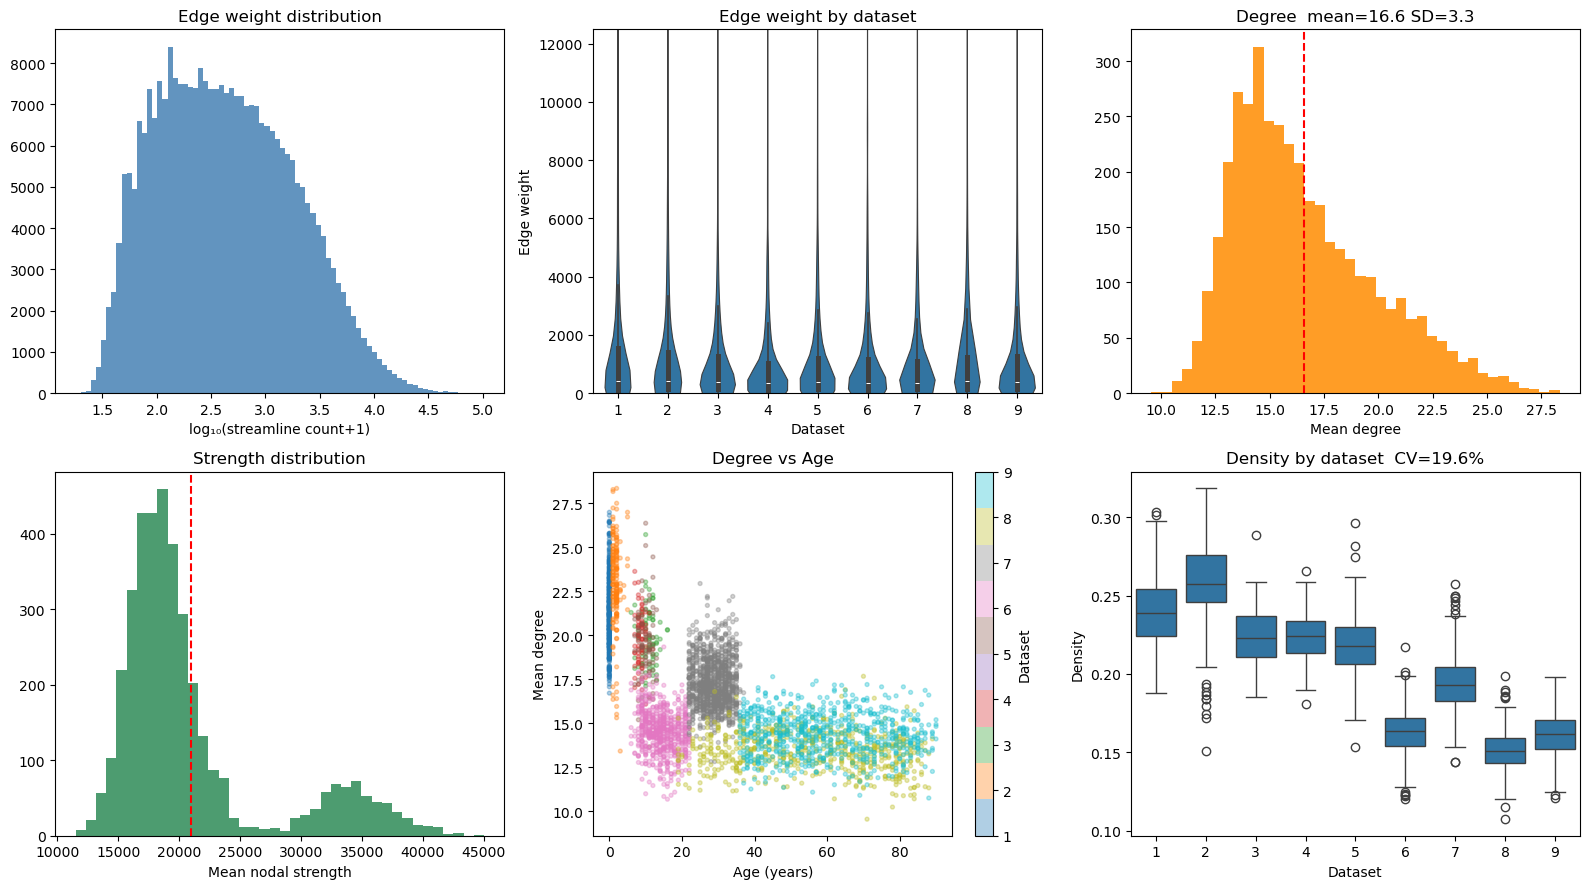

In [13]:

# ── Cell 4: Basic network metrics (degree, strength, density) ─────
N_subj, N_roi, _ = conn.shape
degrees       = np.zeros(N_subj)
mean_strengths= np.zeros(N_subj)
densities     = np.zeros(N_subj)

for i in range(N_subj):
    adj = conn[i].copy(); np.fill_diagonal(adj, 0)
    k   = (adj > 0).sum(axis=1)
    s   = adj.sum(axis=1)
    degrees[i]        = k.mean()
    mean_strengths[i] = s.mean()
    densities[i]      = (adj > 0).sum() / (N_roi * (N_roi - 1))

demo['mean_degree']  = degrees
demo['mean_strength']= mean_strengths
demo['Density']      = densities

print(f"\nDegree:   mean={degrees.mean():.1f}  SD={degrees.std():.1f}")
print(f"Density:  mean={densities.mean():.4f}  CV={100*densities.std()/densities.mean():.1f}%")

# ── Cell 5: Distribution plots ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Sample some edge weights for plotting
sample_idx = np.random.choice(N_subj, min(N_subj, 400), replace=False)
edge_w = []
edge_age = []
edge_ds  = []
for i in sample_idx:
    adj = conn[i].copy(); np.fill_diagonal(adj, 0)
    up  = adj[np.triu_indices(N_roi, k=1)]
    nz  = up[up > 0]
    edge_w.extend(nz.tolist())
    edge_age.extend([demo['age'].iloc[i]] * len(nz))
    edge_ds.extend([demo['dataset'].iloc[i]] * len(nz))
edge_w   = np.array(edge_w)
edge_age = np.array(edge_age)
edge_ds  = np.array(edge_ds)

axes[0,0].hist(np.log10(edge_w + 1), bins=80, color='steelblue', alpha=0.85)
axes[0,0].set(xlabel='log₁₀(streamline count+1)', title='Edge weight distribution')

df_w = pd.DataFrame({'dataset': edge_ds.astype(int).astype(str), 'weight': edge_w})
# subsample per dataset for violin
sub = df_w.groupby('dataset').apply(lambda x: x.sample(min(len(x),1500))).reset_index(drop=True)
sns.violinplot(data=sub, x='dataset', y='weight', ax=axes[0,1], inner='box', linewidth=0.8)
axes[0,1].set(xlabel='Dataset', ylabel='Edge weight', title='Edge weight by dataset')
axes[0,1].set_ylim(0, np.percentile(edge_w, 99))

axes[0,2].hist(degrees, bins=40, color='darkorange', alpha=0.85)
axes[0,2].axvline(degrees.mean(), color='red', linestyle='--')
axes[0,2].set(xlabel='Mean degree', title=f'Degree  mean={degrees.mean():.1f} SD={degrees.std():.1f}')

axes[1,0].hist(mean_strengths, bins=40, color='seagreen', alpha=0.85)
axes[1,0].axvline(mean_strengths.mean(), color='red', linestyle='--')
axes[1,0].set(xlabel='Mean nodal strength', title='Strength distribution')

sc = axes[1,1].scatter(demo['age'], degrees, c=demo['dataset'], cmap='tab10', alpha=0.35, s=8)
plt.colorbar(sc, ax=axes[1,1], label='Dataset')
axes[1,1].set(xlabel='Age (years)', ylabel='Mean degree', title='Degree vs Age')

df_dens = pd.DataFrame({'dataset': demo['dataset'].astype(str), 'density': densities})
sns.boxplot(data=df_dens, x='dataset', y='density', ax=axes[1,2])
axes[1,2].set(xlabel='Dataset', ylabel='Density',
              title=f'Density by dataset  CV={100*densities.std()/densities.mean():.1f}%')

plt.tight_layout()
plt.savefig('results/connectome_distributions.png', dpi=180, bbox_inches='tight')
plt.show()

Threshold range: 73 – 426  median=134


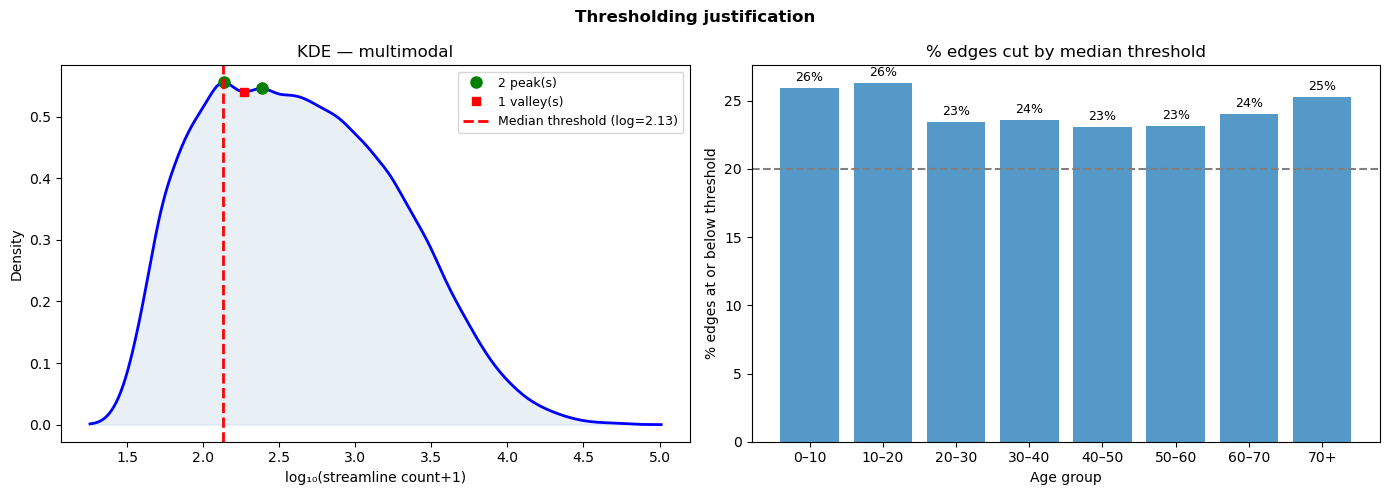

In [14]:

# ── Cell 6: Thresholding justification ───────────────────────────
mat = __import__('scipy.io', fromlist=['loadmat']).loadmat(
    'preprocdata/thresholded_data.mat', simplify_cells=True)
var_thr = np.array(mat['thresholded_data']['thresholds']['variable']).flatten()
print(f"Threshold range: {var_thr.min():.0f} – {var_thr.max():.0f}  median={np.median(var_thr):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Thresholding justification", fontweight='bold')

# KDE on log scale
w_log = np.log10(edge_w[edge_w > 0] + 1)
kde   = gaussian_kde(w_log, bw_method=0.1)
x_log = np.linspace(w_log.min(), w_log.max(), 500)
y_kde = kde(x_log)
peaks, _   = find_peaks(y_kde, height=0.05*y_kde.max(), distance=20)
valleys, _ = find_peaks(-y_kde, distance=20)
axes[0].plot(x_log, y_kde, 'b-', lw=2)
axes[0].fill_between(x_log, 0, y_kde, alpha=0.12, color='steelblue')
axes[0].plot(x_log[peaks],   y_kde[peaks],   'go', ms=8, label=f'{len(peaks)} peak(s)')
axes[0].plot(x_log[valleys], y_kde[valleys], 'rs', ms=6, label=f'{len(valleys)} valley(s)')
thr_log = np.log10(np.median(var_thr) + 1)
axes[0].axvline(thr_log, color='red', linestyle='--', lw=2,
                label=f'Median threshold (log={thr_log:.2f})')
axes[0].set(xlabel='log₁₀(streamline count+1)', ylabel='Density',
            title=f'KDE — {"multimodal" if len(peaks)>1 else "unimodal"}')
axes[0].legend(fontsize=9)

# % edges cut per age group
age_bins   = [0,10,20,30,40,50,60,70,100]
age_labels = ['0–10','10–20','20–30','30–40','40–50','50–60','60–70','70+']
pct_cut = [100*np.mean(edge_w[(edge_age>=lo)&(edge_age<hi)] <= np.median(var_thr))
           if np.any((edge_age>=lo)&(edge_age<hi)) else np.nan
           for lo, hi in zip(age_bins[:-1], age_bins[1:])]
axes[1].bar(age_labels, pct_cut, color='#2980B9', alpha=0.8)
axes[1].axhline(20, color='grey', linestyle='--')
axes[1].set(xlabel='Age group', ylabel='% edges at or below threshold',
            title='% edges cut by median threshold')
for j,(lbl,pct) in enumerate(zip(age_labels,pct_cut)):
    if not np.isnan(pct):
        axes[1].text(j, pct+0.5, f'{pct:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/thresholding/threshold_justification.png', dpi=180, bbox_inches='tight')
plt.show()


In [18]:


# ── Cell 7: Compute Disparity Y_obs, Y_null, Ratio, Deviation ────
def compute_disparity_metrics(adj):
    """
    Per-subject global disparity metrics.
    Returns Y_obs, Y_null, Ratio, mean_degree
    using PER-NODE degree (not mean network degree).
    """
    np.fill_diagonal(adj, 0)
    k = (adj > 0).sum(axis=1).astype(float)      # per-node degree
    s = adj.sum(axis=1)                           # per-node strength

    # Disparity Y_i = sum_j (w_ij/s_i)^2
    s_safe = np.where(s > 0, s, 1.0)
    frac   = adj / s_safe[:, None]
    Y_i    = np.sum(frac**2, axis=1)             # per-node

    # Y_null_i = 2/(k_i + 1)
    Y_null_i = np.where(k > 0, 2.0 / (k + 1.0), np.nan)

    # Ratio_i = Y_i / Y_null_i  (only where k>0)
    ratio_i = np.where(k > 0, Y_i / Y_null_i, np.nan)

    # Global means (mask isolated nodes)
    valid = k > 0
    return {
        'Y_obs'        : np.nanmean(Y_i[valid]),
        'Y_null'       : np.nanmean(Y_null_i[valid]),
        'Disparity_Ratio': np.nanmean(ratio_i[valid]),   # mean of per-node ratios
        'mean_degree'  : k[valid].mean()
    }

print("Computing disparity metrics...")
metrics = [compute_disparity_metrics(conn[i]) for i in range(N_subj)]
metrics_df = pd.DataFrame(metrics)

demo['Disparity_Y']     = metrics_df['Y_obs'].values
demo['Y_null']          = metrics_df['Y_null'].values
demo['Disparity_Ratio'] = metrics_df['Disparity_Ratio'].values

print(f"\nY_obs:  mean={demo['Disparity_Y'].mean():.4f}  SD={demo['Disparity_Y'].std():.4f}")
print(f"Y_null: mean={demo['Y_null'].mean():.4f}  SD={demo['Y_null'].std():.4f}")
print(f"Ratio:  mean={demo['Disparity_Ratio'].mean():.3f}  SD={demo['Disparity_Ratio'].std():.3f}")
print(f"Ratio > 1: {100*np.mean(demo['Disparity_Ratio']>1):.1f}%")


Computing disparity metrics...

Y_obs:  mean=0.2162  SD=0.0309
Y_null: mean=0.1570  SD=0.0316
Ratio:  mean=1.541  SD=0.150
Ratio > 1: 100.0%


Computing disparity metrics...

Y_obs:  mean=0.2162  SD=0.0309
Y_null: mean=0.1570  SD=0.0316
Ratio:  mean=1.541  SD=0.150
Ratio > 1: 100.0%


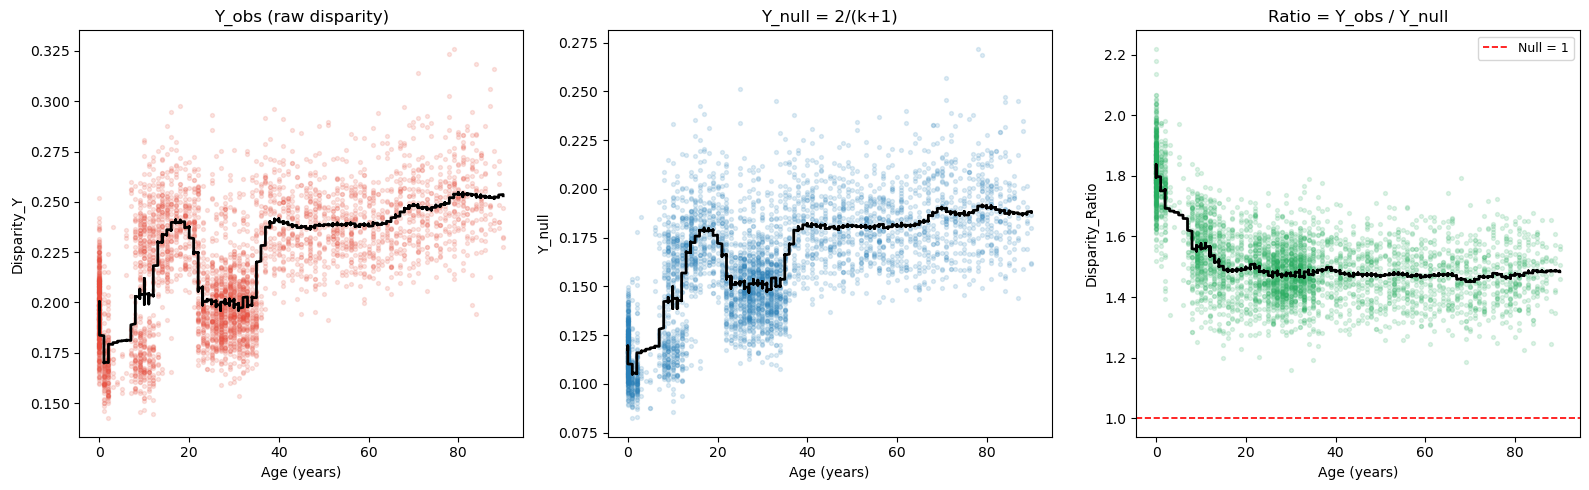

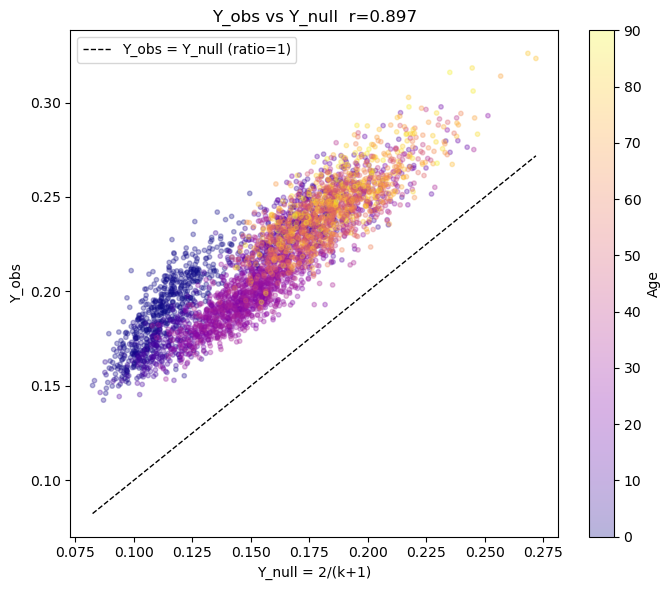

cor(Y_obs, Y_null) = 0.8972
Computing modularity for 3889 subjects (parallel)...
Q: mean=0.509  SD=0.031  range [0.414, 0.640]


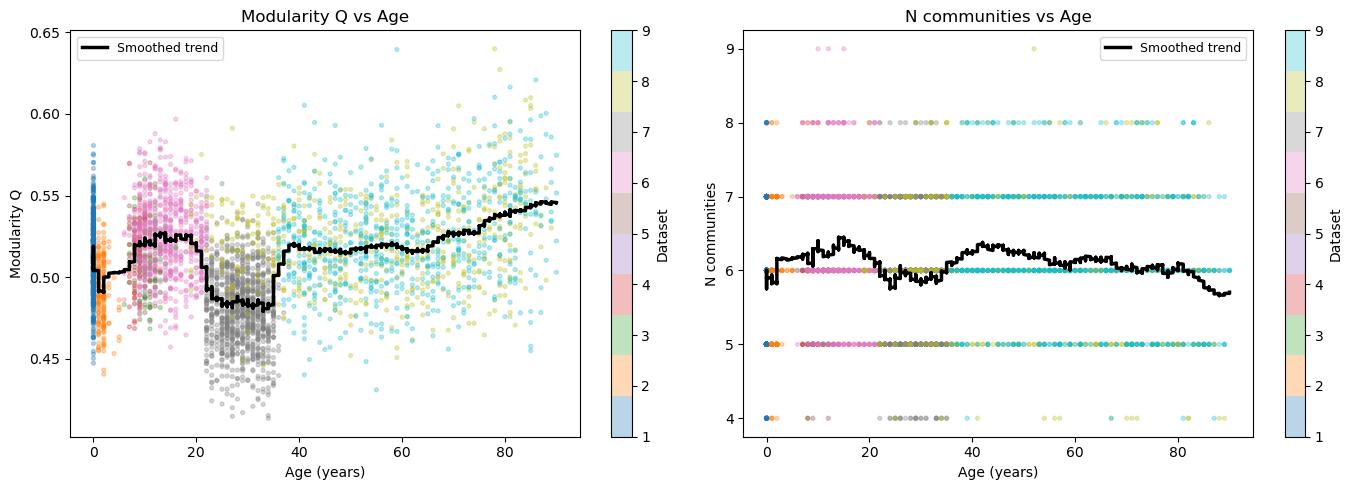

In [ ]:

# ── Cell 8: Disparity plots ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, color, title in zip(
    axes,
    ['Disparity_Y', 'Y_null', 'Disparity_Ratio'],
    ['#E74C3C', '#2980B9', '#27AE60'],
    ['Y_obs (raw disparity)', 'Y_null = 2/(k+1)', 'Ratio = Y_obs / Y_null']
):
    ax.scatter(demo['age'], demo[col], alpha=0.15, s=8, color=color)
    # loess-style smooth
    sort_i  = np.argsort(demo['age'].values)
    age_s   = demo['age'].values[sort_i]
    val_s   = demo[col].values[sort_i]
    smooth  = uniform_filter1d(val_s, size=max(len(val_s)//30, 10))
    ax.plot(age_s, smooth, 'k-', lw=2)
    if col == 'Disparity_Ratio':
        ax.axhline(1, color='red', linestyle='--', lw=1.2, label='Null = 1')
        ax.legend(fontsize=9)
    ax.set(xlabel='Age (years)', ylabel=col, title=title)

plt.tight_layout()
plt.savefig('results/disparity/disparity_metrics_vs_age.png', dpi=180, bbox_inches='tight')
plt.show()

# Y_obs vs Y_null scatter
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(demo['Y_null'], demo['Disparity_Y'],
                c=demo['age'], cmap='plasma', alpha=0.3, s=10)
plt.colorbar(sc, ax=ax, label='Age')
lo, hi = demo['Y_null'].min(), demo['Y_null'].max()
ax.plot([lo,hi],[lo,hi],'k--',lw=1, label='Y_obs = Y_null (ratio=1)')
r = np.corrcoef(demo['Y_null'], demo['Disparity_Y'])[0,1]
ax.set(xlabel='Y_null = 2/(k+1)', ylabel='Y_obs',
       title=f'Y_obs vs Y_null  r={r:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('results/disparity/yobs_vs_ynull.png', dpi=180, bbox_inches='tight')
plt.show()
print(f"cor(Y_obs, Y_null) = {r:.4f}")

# ── Cell 9: Modularity — parallel computation ─────────────────────
def _modularity_subject(adj_i):
    adj = adj_i.copy(); np.fill_diagonal(adj, 0)
    G   = nx.from_numpy_array(adj)
    G.remove_nodes_from(list(nx.isolates(G)))
    if G.number_of_edges() == 0:
        return np.nan, np.nan
    comms = nx.community.greedy_modularity_communities(G, weight='weight')
    Q     = nx.community.modularity(G, comms, weight='weight')
    return float(Q), float(len(comms))

print(f"Computing modularity for {N_subj} subjects (parallel)...")
results = Parallel(n_jobs=-1, prefer='processes')(
    delayed(_modularity_subject)(conn[i]) for i in range(N_subj)
)
Q_vals = np.array([r[0] for r in results])
n_comm = np.array([r[1] for r in results])

demo['modularity_Q']   = Q_vals
demo['n_communities']  = n_comm

print(f"Q: mean={np.nanmean(Q_vals):.3f}  SD={np.nanstd(Q_vals):.3f}  "
      f"range [{np.nanmin(Q_vals):.3f}, {np.nanmax(Q_vals):.3f}]")

# ── Cell 10: Modularity plots ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ['modularity_Q', 'n_communities'],
                           ['Modularity Q', 'N communities']):
    sc = ax.scatter(demo['age'], demo[col],
                    c=demo['dataset'], cmap='tab10', alpha=0.3, s=8)
    sort_i  = np.argsort(demo['age'].values)
    age_s   = demo['age'].values[sort_i]
    val_s   = demo[col].values[sort_i]
    smooth  = uniform_filter1d(val_s, size=max(len(val_s)//30, 10))
    ax.plot(age_s, smooth, 'k-', lw=2.5, label='Smoothed trend')
    ax.set(xlabel='Age (years)', ylabel=title, title=title+' vs Age')
    ax.legend(fontsize=9)
    plt.colorbar(sc, ax=ax, label='Dataset')

plt.tight_layout()
plt.savefig('results/communities/modularity_vs_age.png', dpi=180, bbox_inches='tight')
plt.show()


In [16]:
demo.columns

Index(['age', 'sex', 'dataset', 'atlas', 'group', 'outlier_index',
       'mean_degree', 'mean_strength', 'Density', 'Disparity_Y', 'Y_null',
       'Disparity_Ratio', 'modularity_Q', 'n_communities'],
      dtype='object')

In [ ]:

# ── Cell 11: Save ─────────────────────────────────────────────────
out_path = 'procdata/demographics_with_disparity_dev_unthresholded.csv'
demo.to_csv(out_path, index=False)
print(f"\nSaved {len(demo)} subjects → {out_path}")
print(f"Columns: {demo.columns.tolist()}")
